# Objective: #
Develop variance-based metrics for determining tissue ratios.

In [1]:
import os
import sys
from pathlib import Path
import logging
import warnings
import gc
from datetime import datetime
import multiprocessing as mp
import concurrent.futures
# from tqdm import tqdm
import json
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn as nil
from nilearn.plotting import plot_epi
from nilearn.glm.first_level import make_first_level_design_matrix
from scipy import stats
import argparse
import seaborn as sns

### Saving and Tracking ###

In [2]:
# Set up logging and deal with any warnings.
today = datetime.now().date().strftime("%Y-%m-%d")

logging.basicConfig(
    level=logging.INFO, 
    format="%(asctime)s - %(levelname)s - %(message)s", 
    datefmt="%Y-%m-%d %H:%M:%S", 
    handlers=[
        logging.FileHandler(f"./logs/msc_data_generation_{today}.log", mode='w'), 
        logging.StreamHandler(sys.stdout)
    ]
)

warnings.filterwarnings('ignore')

In [3]:
# A dictionary of all the stuff we'd otherwise have to keep writing out; 
# this way, we only ever have to change things up here.
config = {
    'data_dir': "../data/fmriprep_output/derivatives",
    'raw_dir': "../data/ds000224",
    'roi_mask_suffix': "Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'data_output_dir': 'datasets', 
    'scan_dim_3d': (0,0,0),
    'roi_label': 'roi-ppa_r', #'roi-rnd_wb',
    'roi_coord_MNI': (28, -47, -9), #(-15, -1, -3), #np.random.randint(low=-24,high=24,size=3), #(24, -2, -20),
    'roi_radius': 16,
    'encoding_label': 'encoding-stimxhrf',
    'csv_suffix': 'desc-var_seg_inflection_pts.csv', #'desc-vox_w_stim_hrf.csv',
    'parquet_suffix': 'desc-vox_w_stim_hrf.parquet',
    'output_type': 'csv_suffix',
    'date_suffix': today,
    'nilearn_defaults': {
         'standardize': False, #'psc',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2
        },
    'hrf_model': 'spm'
}

In [4]:
def json_compatibility_encoder(obj):
    """
    A helper function to convert numpy types to python floats  
    and ints to keep the json library from getting mad about 
    type unserializability. If we can't convert to the right 
    numeric type, we go for string type.

    Parameters
    ----------
    obj : numeric, string, or other data types
        Meta data from the global config variable that need
        to be converted into native python types.

    Returns
    -------
    float, int, string
        Converts object into the correct type for the json file.
    """
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

In [5]:
def save_dataset_with_metadata(df, config, today_date, voxel_dims, applied_nil_params):
    """
    Saves the dataframe and its metadata to a unique, programmatically named directory
    to prevent dataset over-writing and to ensure dataset generation traceability.

    Parameters
    ----------
    df : pandas.DataFrame
        Fully processed and concatenated pandas dataframe containing timeseries for voxels in ROI.
    config : dict
        Dictionary containing all parameters for dataset generation.
    today_date : str
        A string representing the current date (e.g., "YYYY-MM-DD") used for naming.
    voxel_dims : tuple of float
        A tuple containing the x, y, and z dimensions of the functional scan voxels.
    applied_nil_params : dict
        A dictionary containing the precise nilearn parameters applied during the time series extraction.

    Returns
    -------
    None
        The function saves the dataframe as a Parquet file and the metadata as a JSON 
        file directly to the disk.
    """
    gen_id = f"dataset_{config['task_label']}_{config['roi_label']}"
    
    gen_dir = os.path.join(config['data_output_dir'], gen_id)
    os.makedirs(gen_dir, exist_ok=True)

    coord_array =  "_".join(map(str, config['roi_coord_MNI']))
    parquet_path = os.path.join(gen_dir, "_".join([gen_id, coord_array, f"date-{today_date}", config['parquet_suffix']]))
    json_path = os.path.join(gen_dir, "_".join([gen_id, coord_array, f"date-{today_date}", "metadata.json"]))
    
    metadata = {
        "generation_id": gen_id,
        "generation_date": today_date,
        "base_configuration": config,
        "updated_config_params": {
            "voxel_dimensions": voxel_dims,
            "applied_nil_params": applied_nil_params
        },
        "data_summary": {
            "total_rows": len(df),
            "subjects": df['subj'].unique().tolist() if 'subj' in df.columns else "N/A",
            "sessions": df['sess'].unique().tolist() if 'sess' in df.columns else "N/A",
            "columns": df.columns.tolist()
        }
    }
    
    df.columns = df.columns.astype(str)
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    
    with open(json_path, 'w') as f:
        json.dump(metadata, f, indent=4, default=json_compatibility_encoder)
        
    logging.info("Successfully saved unique dataset and metadata to: %s", parquet_path)

### Utilities ###

In [6]:
template_img_path = '../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz'

In [7]:
def get_run_paths(sub_id, ses_id, config):
    """
    Generates all required file paths for a given subject and session run.

    Parameters
    ----------
    sub_id: int
        The number portion of the subject identifier (e.g., sub-MSC05 -> 5).
    ses_id: int
        The number portion of the session identifier for the subject above
        (e.g., ses-func09 -> 9).
    config: dict
        The dictionary outlining the basic parameters of this dataset creation.

    Returns
    -------
    dict
        A dictionary mapping path keys (e.g., 'brain', 'mask', 'confounds', 'events', 
        'skull_stripped', 'output_file') to their absolute string path locations.
    """
    # Automatically zero-pad integers to 2 digits because that's how MSC rolls.
    sub_str = f"{config['subj_prefix']}{sub_id:02d}"
    ses_str = f"{config['sess_prefix']}{ses_id:02d}"
    
    # Define base directories using pathlib.
    data_dir = Path(config['data_dir']) / sub_str / ses_str / 'func'
    raw_dir = Path(config['raw_dir']) / sub_str / ses_str / 'func'
    out_dir = Path(config['data_output_dir'])
    
    # Create dictionary of paths for each object.
    coord_array = "_".join(map(str, config['roi_coord_MNI']))
    paths = {
        'brain': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_{config['bold_suffix']}",
        'mask': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_{config['mask_suffix']}",
        'confounds': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['confounds_suffix']}",
        'events': raw_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['events_suffix']}",
        # 'sphere': out_dir / f"{sub_str}_{ses_str}_{config['roi_label']}_{config['roi_coord_MNI']}_{config['roi_mask_suffix']}",
        'skull_stripped': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_desc-skull_stripped_preproc_bold.nii.gz",
        'output_file': data_dir.parent / 'datasets' / f"{sub_str}_{ses_str}_{config['task_label']}_{config['roi_label']}_{coord_array}_{config['encoding_label']}_{config['date_suffix']}_{config[config['output_type']]}"
    }
    
    # Convert pathlib Path objects back to strings for use in other functions.
    return {k: str(v) for k, v in paths.items()}

### Data Extraction ###

In [8]:
def calculate_kde(tsxvx):
    tv_var = np.var(tsxvx, dtype=np.float64, axis=0, ddof=1)
    kern = stats.gaussian_kde(tv_var)
    return kern

### Functions and Useful Code ###

In [17]:
def inflection_pointer(kde):
    x_grid = np.linspace(kde.dataset.min(), kde.dataset.max(), 1000)
    kde_eval = kde(x_grid)
    kde_eval_d1 = np.gradient(kde_eval)
    kde_eval_d2 = np.gradient(kde_eval_d1)
    inflections = np.where(np.diff(np.sign(kde_eval_d2)))
    return x_grid[inflections[0]]

In [18]:
def var_img_to_df(nib_img):
    coords_dict = {'x':[], 'y':[], 'z':[], 'var':[]}
    for i in range(nib_img.get_fdata().shape[0]):
        for j in range(nib_img.get_fdata().shape[1]):
            for k in range(nib_img.get_fdata().shape[2]):
                coords_dict['x'].append(i)
                coords_dict['y'].append(j)
                coords_dict['z'].append(k)
                coords_dict['var'].append(nib_img.get_fdata()[i,j,k,0])
    cdf = pd.DataFrame(coords_dict)
    return cdf

In [19]:
def vox_segmentor(var_df, inflection_points):
    vdf = var_df[var_df['var']!=0.0]
    vdf['segment'] = np.zeros(vdf.shape[0])
    for i,n in enumerate(ifs):
        if i==0:
            vdf['segment'][vdf['var']<=n] += i+1
        else:
            vdf['segment'][(vdf['var']<=n) & (vdf['var']>ifs[i-1])] += i+1
    return vdf

In [31]:
# vdf for each session
# Generate the spherical ROI Mask if necessary
os.makedirs(config['data_output_dir'], exist_ok=True)
ROI_mask_path = os.path.join(config['data_output_dir'], f"global_{config['roi_label']}_{config['roi_coord_MNI']}_mask.nii.gz")

logging.info("Generating global ROI sphere mask...")
template_img = nib.load(template_img_path)
template_dims = template_img.header.get_zooms()[:3]
ROI_mask = ROI_sphere(template_img_path, config['roi_coord_MNI'], template_dims, config['roi_radius'])
nib.save(ROI_mask, ROI_mask_path)


# Initialize metadata params
last_voxel_dims = None
last_nil_params = None
kern_list = []
for sub in range(1, 11):
    for ses in range(1, 15):
        paths = get_run_paths(sub, ses, config)
        if os.path.isfile(paths['brain']):
            brain_img = nib.load(paths['skull_stripped'])
            
            cfdf = pd.read_csv(paths['confounds'], header=0, sep="\t")
            basic_confounds = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
            cfdf = cfdf[basic_confounds].fillna(0)

            sphere_masker = nil.maskers.NiftiMasker(ROI_mask, smoothing_fwhm=None, standardize=False, standardize_confounds=False, 
                                   detrend=False, high_variance_confounds=False, low_pass=None, high_pass=None, 
                                   t_r=brain_img.header.get_zooms()[3], dtype=np.float64)
            sphere_ts = sphere_masker.fit_transform(brain_img, confounds=cfdf)
            sphere_var = calculate_kde(sphere_ts)

            ifs = inflection_pointer(sphere_var)
            data = sphere_var.dataset[0]
            var_img = unmask(sphere_var.dataset, ROI_mask)

            coord_var_df = var_img_to_df(var_img)
            seg_vox_df = vox_segmentor(coord_var_df, ifs)
            seg_vox_df.to_csv(paths['output_file'])
            print(f"Saved subject {sub}, session {ses} to \n {paths['output_file']}.")
        else:
            print(f"Skipped MSC Subj {sub}, Session {ses}.")

2026-04-23 07:13:26 - INFO - Generating global ROI sphere mask...
2026-04-23 07:13:26 - INFO - Initiating ROI mask creation for coordinate: (28, -47, -9).
Saved subject 1, session 1 to 
 ../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/datasets/sub-MSC01_ses-func01_task-memoryscenes_roi-ppa_r_28_-47_-9_encoding-stimxhrf_2026-04-23_desc-var_seg_inflection_pts.csv.
Saved subject 1, session 2 to 
 ../data/fmriprep_output/derivatives/sub-MSC01/ses-func02/datasets/sub-MSC01_ses-func02_task-memoryscenes_roi-ppa_r_28_-47_-9_encoding-stimxhrf_2026-04-23_desc-var_seg_inflection_pts.csv.
Saved subject 1, session 3 to 
 ../data/fmriprep_output/derivatives/sub-MSC01/ses-func03/datasets/sub-MSC01_ses-func03_task-memoryscenes_roi-ppa_r_28_-47_-9_encoding-stimxhrf_2026-04-23_desc-var_seg_inflection_pts.csv.
Saved subject 1, session 4 to 
 ../data/fmriprep_output/derivatives/sub-MSC01/ses-func04/datasets/sub-MSC01_ses-func04_task-memoryscenes_roi-ppa_r_28_-47_-9_encoding-stimxhrf_2026-04-23_de

For a voxel to believably be related to the signal I'm looking for, I need to meet the following criteria:
1. A biologically valid signal-containing voxel must be contiguous with another such voxel.
2. The voxels themselves must contain similar numbers of changepoints. (how to find?)
3. The valid signal occupies at least a third of the ROI sphere and at most two thirds of the ROI sphere.
4. 

## Testing Area ##

### Test Code Bits ###

#### KDE Spaghetti Code ####

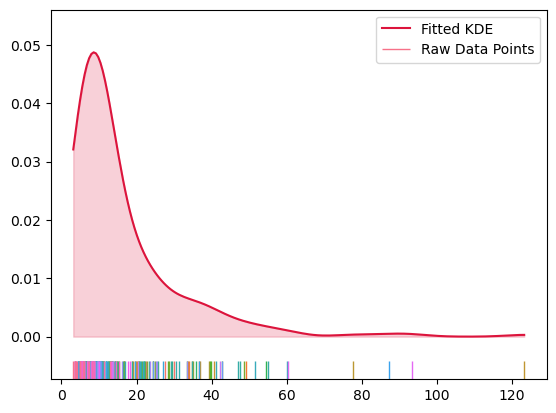

In [21]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fit your KDE
kde = kern_list[9]
data = kde.dataset

# 2. Map the line
x_grid = np.linspace(data.min(), data.max(), 200)
y_density = kde(x_grid)

# 3. Plot the extracted line
plt.plot(x_grid, y_density, color="crimson", label="Fitted KDE")
plt.fill_between(x_grid, y_density, alpha=0.2, color="crimson") # Fill under curve

# 4. Plot the source data as ticks at the bottom (Rug plot)
sns.rugplot(data, color="black", height=0.05, label="Raw Data Points")

plt.legend()
plt.show()


Okay, let's take a look at the coordinates of each voxel along with its variance. We'll do, x, y (grid) and the variance can be color. We'll also do it on a brain just to see. Nilearn has plotting methods for stat maps, which is what we will treat the mask as. Instead of doing this as part of the above code, we'll just write some specifically for this task.

In [22]:
path_dct['skull_stripped']

'../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz'

In [23]:
path_dct = get_run_paths(1,1,config)
sphere_mask = nib.load(ROI_mask_path)
brain_img = nib.load(path_dct['skull_stripped'])

cfdf = pd.read_csv(path_dct['confounds'], header=0, sep="\t")
basic_confounds = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']
cfdf = cfdf[basic_confounds].fillna(0)

FEF_mask = nil.maskers.NiftiMasker(sphere_mask, smoothing_fwhm=None, standardize=False, standardize_confounds=False, 
                                   detrend=False, high_variance_confounds=False, low_pass=None, high_pass=None, 
                                   t_r=brain_img.header.get_zooms()[3], dtype=np.float64)
FEF_ts = FEF_mask.fit_transform(brain_img, confounds=cfdf)

In [24]:
FEF_var = calculate_kde(FEF_ts)

# FEF_var = np.var(FEF_ts, dtype=np.float64, axis=0, ddof=1)
# kde = stats.gaussian_kde(FEF_var)

In [25]:
FEF_ts.shape

(121, 264)

In [26]:
data.shape

(1, 264)

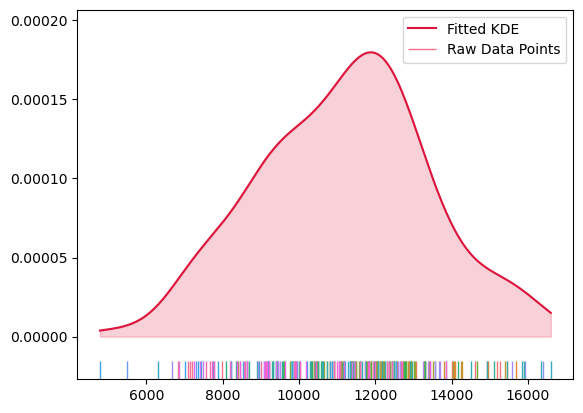

In [28]:
# 2. Map the line
x_grid = np.linspace(FEF_var.dataset.min(), FEF_var.dataset.max(), 200)
y_density = FEF_var(x_grid)

# 3. Plot the extracted line
plt.plot(x_grid, y_density, color="crimson", label="Fitted KDE")
plt.fill_between(x_grid, y_density, alpha=0.2, color="crimson") # Fill under curve
# plt.xlim(0.8,1.2)
# 4. Plot the source data as ticks at the bottom (Rug plot)
sns.rugplot(FEF_var.dataset, color="black", height=0.05, label="Raw Data Points")

plt.legend()
plt.show()


In [28]:
from nilearn.masking import unmask

In [ ]:
psc = (FEF_var.dataset-FEF_var.dataset.mean())/FEF_var.dataset.mean()
var_img = unmask(psc, sphere_mask)

In [30]:
import seaborn as sns
import nibabel as nib
import nilearn as nil
from nilearn.plotting import plot_glass_brain

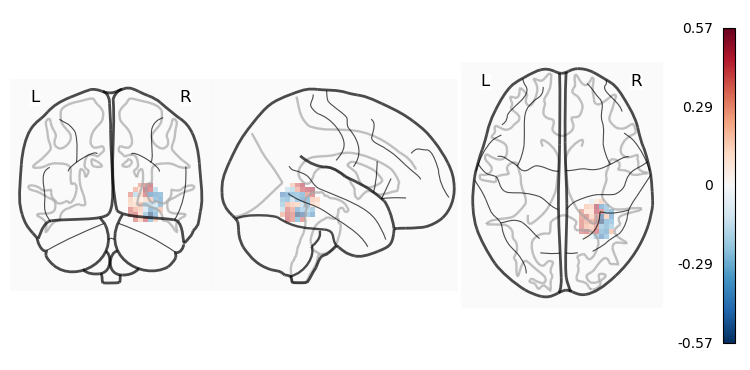

In [56]:
plot_glass_brain(var_img, threshold=None, plot_abs=False, transparency=0.5, display_mode="ortho")

In [90]:
nib.save(var_img, "./ms01ses01_var_img_test3.nii.gz")

Good enough. Let's go find inflection points for these curves.

In [32]:
ifs = inflection_pointer(FEF_var)

In [34]:
data = FEF_var.dataset[0]

In [72]:
var_img = unmask(FEF_var.dataset, sphere_mask)

In [80]:
# plot on grid
import plotly.express as px

fig = px.scatter_3d(vdf[(vdf['segment']>=4)|(vdf['segment']<=7)], x='x', y='y', z='z', color='var', opacity=0.7, size_max=3, title="Variance Over Time in ROI")
fig.show(renderer="iframe")

In [79]:
vdf.to_csv("./variance_in_space_ms01ses01.csv")

In [81]:
keep_data = vdf[(vdf['segment']>=4.0) & (vdf['segment']<=7.0)][['x','y','z']]
var_mask = np.zeros(sphere_mask.get_fdata().shape)
keep_data = keep_data.to_numpy(dtype=np.int32)

In [83]:
var_mask[keep_data] = 1

In [71]:
vdf['segment'].unique()

array([8.])

In [87]:
var_mask_img = nib.Nifti1Image(var_mask, sphere_mask.affine, sphere_mask.header)

In [88]:
nib.save(var_mask_img, "./ms01ses01_var_img_seg4-7.nii.gz")

In [90]:
vdf[(vdf['var']>=8000) & (vdf['var']<=14000)]['segment'].unique()

array([6., 5., 7., 3., 4.])

#### Prob Seg Study ####

In [13]:
# Load a brain and get tissue probabilities.
path_dct = get_run_paths(1,1,config)
print(path_dct['brain'])

../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


In [14]:
gm_probseg_path = "../data/fmriprep_output/derivatives/sub-MSC01/anat/sub-MSC01_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz"
wm_probseg_path = "../data/fmriprep_output/derivatives/sub-MSC01/anat/sub-MSC01_space-MNI152NLin2009cAsym_label-WM_probseg.nii.gz"
csf_probseg_path = "../data/fmriprep_output/derivatives/sub-MSC01/anat/sub-MSC01_space-MNI152NLin2009cAsym_label-CSF_probseg.nii.gz"

In [15]:
gm_ps_img = nib.load(gm_probseg_path)
wm_ps_img = nib.load(wm_probseg_path)
csf_ps_img = nib.load(csf_probseg_path)
brain_img = nib.load(path_dct['skull_stripped'])

In [16]:
gm_prob_seg = gm_ps_img.get_fdata()
gm_prob_seg_high = gm_prob_seg[gm_prob_seg>=0.970]

In [17]:
gm_prob_seg.shape

(241, 286, 241)

In [18]:
from nilearn.image import resample_to_img
bold_gm_ps_img = resample_to_img(source_img=gm_ps_img, target_img=brain_img, interpolation='continuous')
bold_wm_ps_img = resample_to_img(source_img=wm_ps_img, target_img=brain_img, interpolation='continuous')
bold_csf_ps_img = resample_to_img(source_img=csf_ps_img, target_img=brain_img, interpolation='continuous')

In [15]:
sum([bold_gm_ps_img.get_fdata()[25,15,5], bold_wm_ps_img.get_fdata()[25,15,5], bold_csf_ps_img.get_fdata()[25,15,5]])

np.float64(0.9999990684470106)

In [19]:
# empty_brain = np.zeros(bold_gm_ps_img.shape)
idxs_99 = np.argwhere(bold_gm_ps_img.get_fdata()>=0.99)
# gm_99_idx = [[idxs_99[0][i],idxs_99[1][i],idxs_99[2][i]] for i in range(idxs_99[0].shape[0])] 
# empty_brain[idxs_99] += 1

How much of the prob-seg mask has voxels that have 99%+ likelihood of being gray matter?

In [17]:
import math
gm_99.sum()/math.prod(bold_gm_ps_img.get_fdata().shape)

np.float64(0.008269994327850255)

To get contiguous pieces of tissue, we would have to first start with checking the 

In [57]:
def get_neighbors(center_vox):
    cube_range = np.arange(-1, 2)
    i, j, k = np.meshgrid(cube_range, cube_range, cube_range, indexing='ij')
    neighbor_relative_indices = np.stack((i,j,k), axis=-1).reshape(-1,3)
    neighbor_idx = center_vox + neighbor_relative_indices
    return neighbor_idx

In [58]:
def check_valid(center_vox, brain_shape):
    for pos in range(len(center_vox)):
        if (center_vox[pos]>1) & (center_vox[pos]<brain_shape[pos]-2):
            continue
        else:
            return False
    return True

In [82]:
np.linalg.norm(np.array([23,33,17])-np.array([22,35,17]))

np.float64(2.23606797749979)

We want three steps:
pop a voxel from to_check and check if valid and add to valid_neighbors
add neighbors to to_check
add vox to checked

In [60]:
def build_sample(seed_voxel, brain_data, threshold, path):
    valid_neighbors = set()
    checked = set()
    to_check = set([tuple(seed_voxel)])
    while to_check and len(valid_neighbors)<150:
        looking = to_check.pop()
        # print('looking: ', looking)
        # print('voxel info', brain_data[tuple(looking)])
        if (brain_data[tuple(looking)]>=threshold) and check_valid(looking, brain_data.shape):
            valid_neighbors.add(looking)
            neighbors = set(map(tuple,get_neighbors(looking).tolist()))
            # print('neighbors before discard: ', neighbors)
            neighbors.difference_update(neighbors & checked)
            # print('neighbors after discard: ', neighbors)
            to_check.update(neighbors)
        checked.add(looking)
        # print('checked: ', checked)
        # print('valid_neighbors: ', valid_neighbors)
        # print('\n')
    formatted_seed_voxel = "-".join(map(str, seed_voxel))
    with open(f'{path}/center_voxel_{formatted_seed_voxel}.json', 'w') as f:
        json.dump(list(valid_neighbors), f, default=json_compatibility_encoder)
    return True

In [21]:
import json

# with open('test.json', 'w') as f:
#     json.dump(json_compatibility_encoder(test), f)

In [22]:
# select 500 seed voxels
rng = np.random.default_rng()
seeds = rng.choice(idxs_99, size=500, replace=False)

# check whether they are far enough apart
from scipy.spatial.distance import cdist
dist_matrix = cdist(seeds, seeds, metric='euclidean')
closeness = dist_matrix.sum(axis=1)

In [23]:
import seaborn as sns

<Axes: ylabel='Count'>

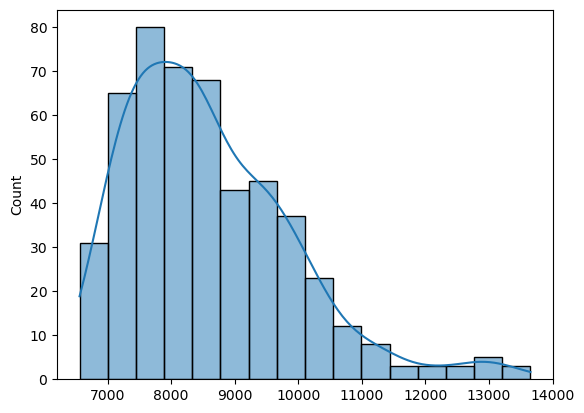

In [24]:
sns.histplot(closeness, bins='auto', kde=True)

In [25]:
counts, edges = np.histogram(closeness, bins='auto')

In [26]:
edges

array([ 6558.85158383,  7002.18147213,  7445.51136043,  7888.84124872,
        8332.17113702,  8775.50102532,  9218.83091362,  9662.16080192,
       10105.49069021, 10548.82057851, 10992.15046681, 11435.48035511,
       11878.81024341, 12322.1401317 , 12765.47002   , 13208.7999083 ,
       13652.1297966 ])

In [27]:
sprouts = idxs_99[np.where(closeness>edges[5])[0]]

In [10]:
data_dir = './datasets/tissue_studies'
os.makedirs(data_dir, exist_ok=True)

In [69]:
safe_workers = 8

context = mp.get_context('fork')

with concurrent.futures.ProcessPoolExecutor(
    max_workers=safe_workers, 
    mp_context=context, 
    # max_tasks_per_child=1
) as executor:
    
    # Submit all tasks to the executor
    futures = {
        executor.submit(build_sample, vxl, bold_gm_ps_img.get_fdata(), 0.85, data_dir): ('seed_vox_'+str(i),vxl) 
        for i, vxl in enumerate(sprouts)
    }
    
    # Catch the results as they finish
    for future in concurrent.futures.as_completed(futures):
        result = future.result()

In [11]:
# build the sample set for analysis
sample_paths = os.listdir(data_dir)
sample_paths = [p for p in sample_paths if p[0]!='.']
sample_data = {}

for name in sample_paths:
    with open(os.path.join(data_dir, name)) as f:
        data = json.load(f)
    indices = list(map(tuple,data))
    sample_data[name[:-5]] = indices


One of the main questions is whether the samples are actually somewhat globular, sheet-like, or simply strips. I can't think of a way to do that cleverly. Adjacency matrix and then use network metrics to determine overall shape. I could also create nifti files and visualize the samples. However, I'd rather use a method that yields a number rather than involving human eyes analysing the characteristics. 
I suppose what really matters is whether the samples are broad or not. One way is to create the adjacency matrix and then add up the edges. More edges -> broader. We can actually do it as a ratio: sum of edges / total possible edges. Honestly, this can be created as we create the sample, but it's cleaner if it's its own step.
Another thought, we actually need multiple thresholds sampled for multiple brains. For now, let's see what these mostly-GM samples are like.

In [16]:
s01_ss01_paths = get_run_paths(1,1,config)
s01_ss01_brain = nib.load(s01_ss01_paths['skull_stripped'])

In [21]:
samp_centers = list(sample_data.keys())

In [48]:
samp_vars = np.zeros((150,len(samp_centers)))

for i, cent in enumerate(samp_centers):
    
    for j, samp in enumerate(sample_data[cent]):
        samp_vars[j,i] = np.var(s01_ss01_brain.get_fdata()[*samp])
        

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: ylabel='Count'>

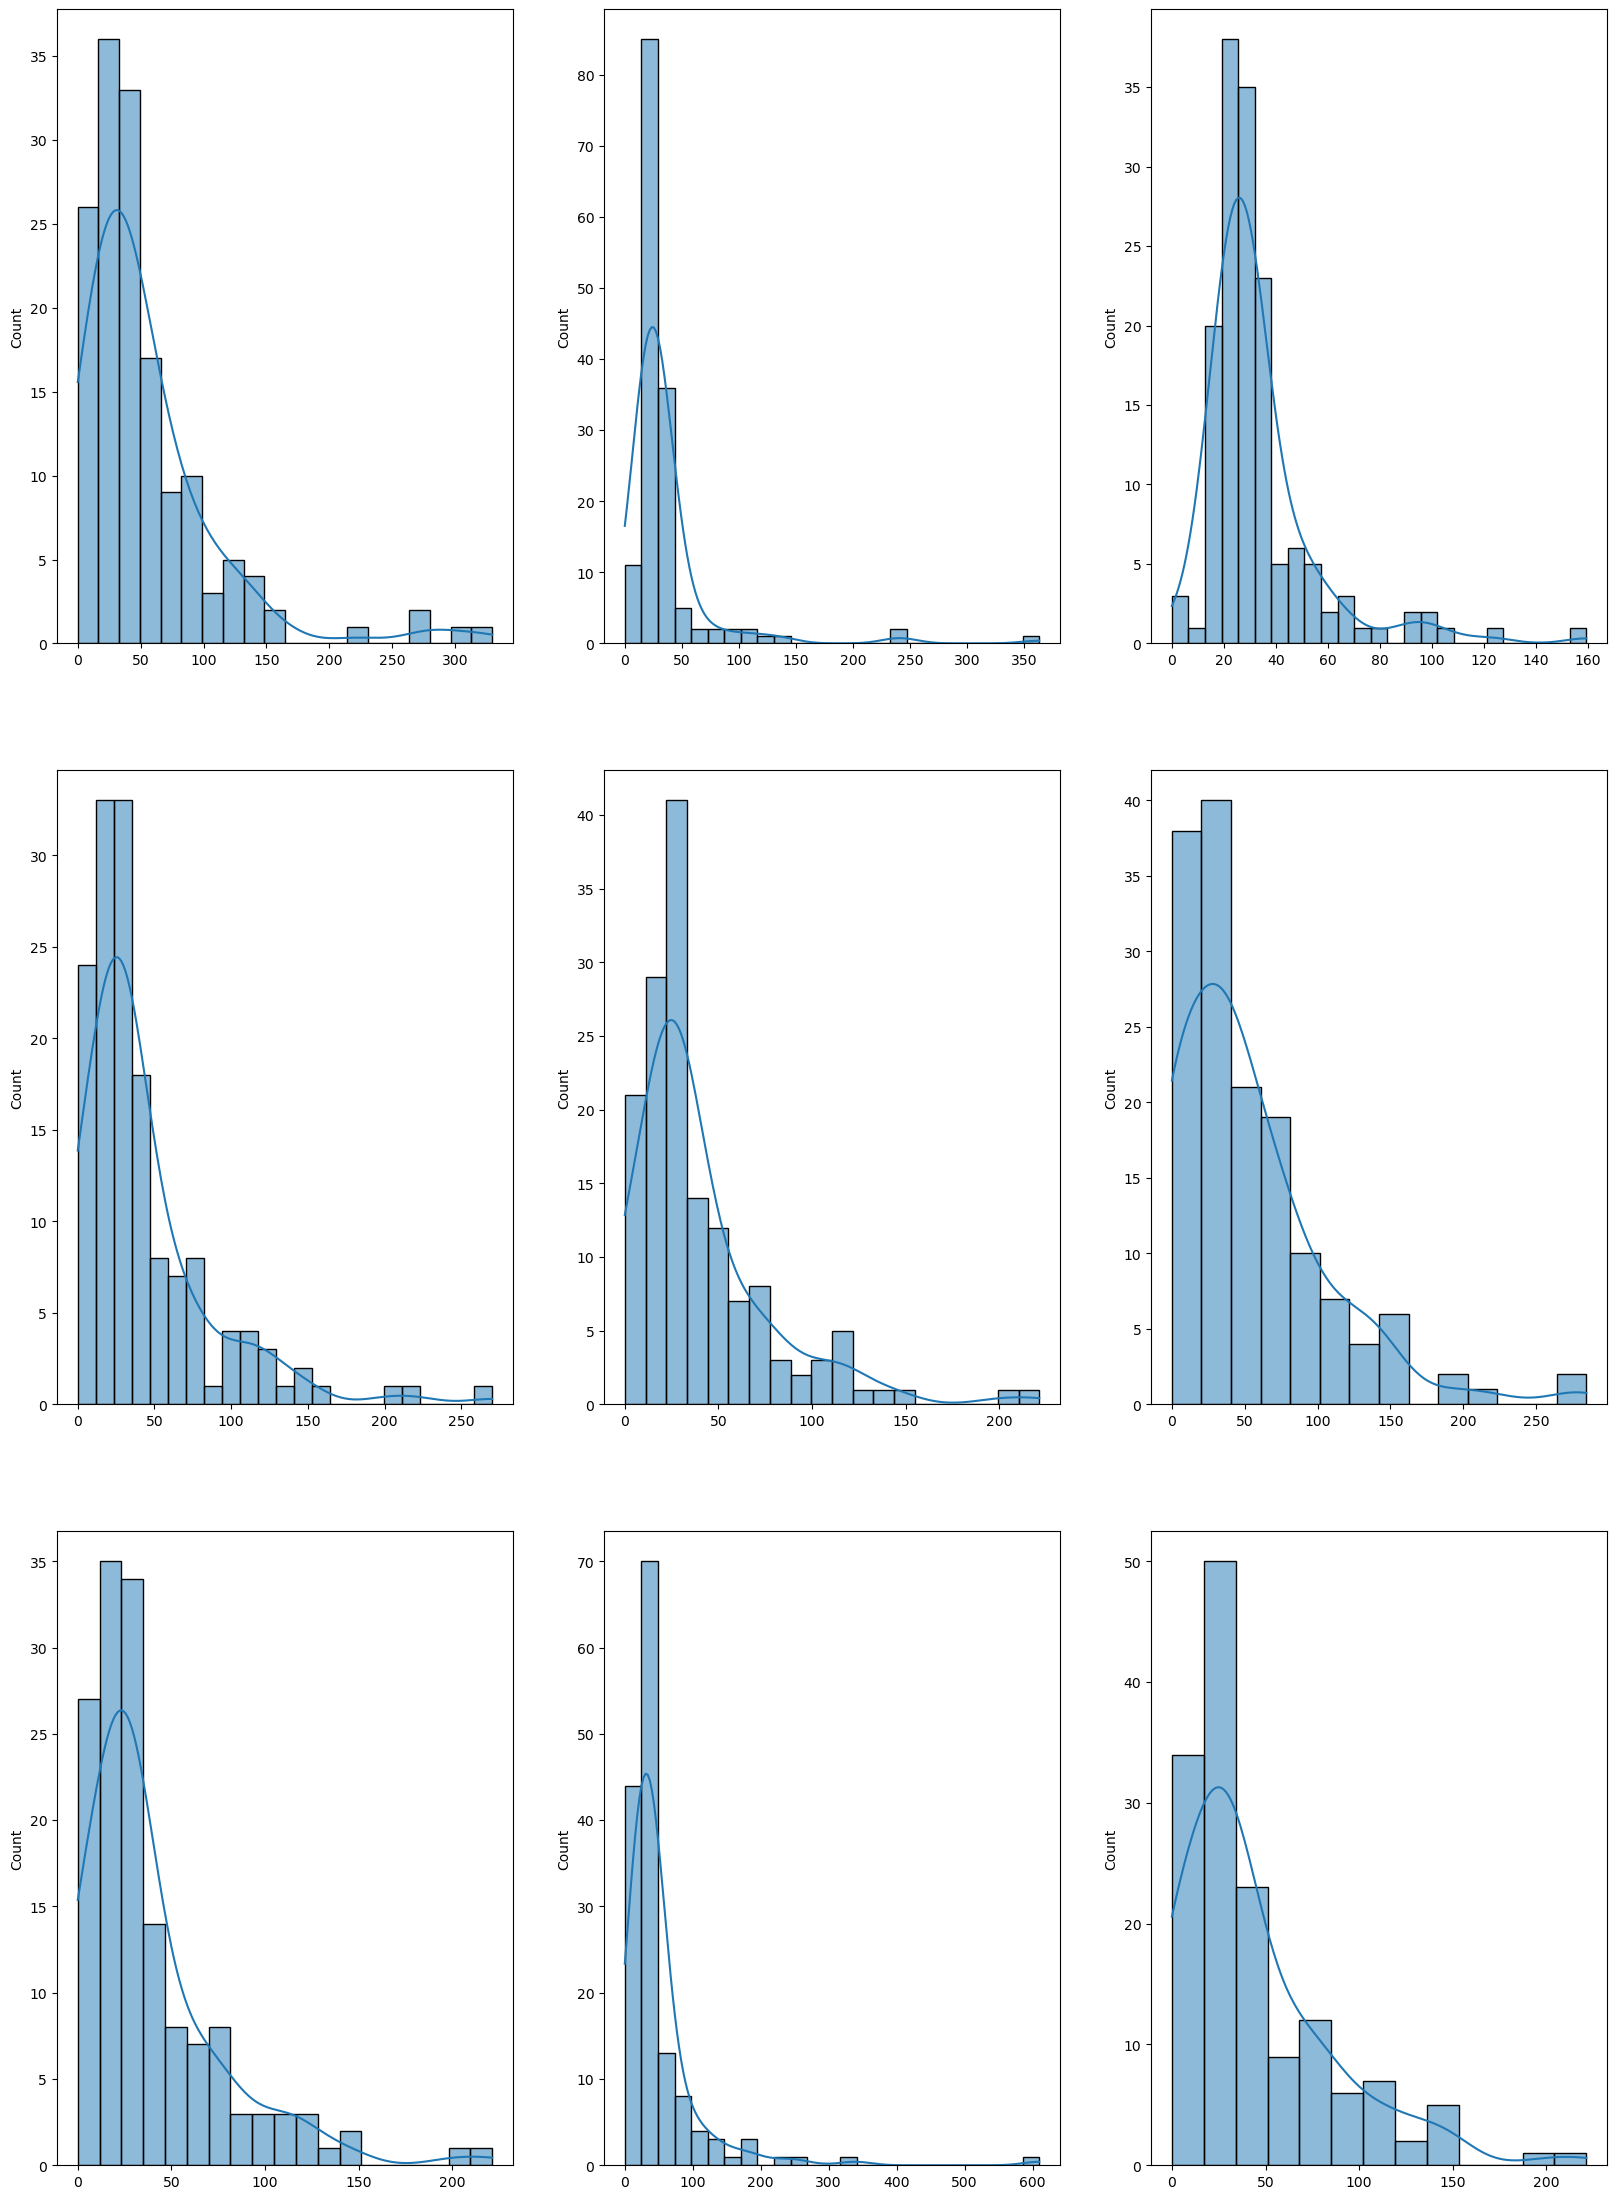

In [56]:
fig, ax = plt.subplots(3,3, figsize=(20,28))
sns.histplot(samp_vars[:,0], bins='auto', kde=True, ax=ax[0,0])
sns.histplot(samp_vars[:,7], bins='auto', kde=True, ax=ax[0,1])
sns.histplot(samp_vars[:,19], bins='auto', kde=True, ax=ax[0,2])
sns.histplot(samp_vars[:,30], bins='auto', kde=True, ax=ax[1,0])
sns.histplot(samp_vars[:,57], bins='auto', kde=True, ax=ax[1,1])
sns.histplot(samp_vars[:,109], bins='auto', kde=True, ax=ax[1,2])
sns.histplot(samp_vars[:,130], bins='auto', kde=True, ax=ax[2,0])
sns.histplot(samp_vars[:,167], bins='auto', kde=True, ax=ax[2,1])
sns.histplot(samp_vars[:,180], bins='auto', kde=True, ax=ax[2,2])

# Let's run everything! #

In [4]:
sys.path.append(str(Path.cwd().parent / 'src'))
import tissue_studies_sample_generation

In [5]:
notebook_args = argparse.Namespace(
    config="../configs/tissue_studies.json", 
    sub=1,
    ses=1,
    threshold=0.85, 
    workers=10
)